In [87]:
import matplotlib.pyplot as plt
import numpy as np
import pickle

from scipy.signal import find_peaks
from circadian_feeding import simulate, plot, experimental_data
from circadian_feeding.food import TRE
from circadian_feeding.params import num
import replicate_figiures

import importlib
importlib.reload(plot)
importlib.reload(simulate)

%load_ext autoreload                             
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [88]:
simulate.simulate_sfs()

SimResult(t_s=array([0.000000e+00, 1.000000e-01, 2.000000e-01, ..., 5.183997e+05,
       5.183998e+05, 5.183999e+05], shape=(5184000,)), t_h=array([0.00000000e+00, 2.77777778e-05, 5.55555556e-05, ...,
       1.43999917e+02, 1.43999944e+02, 1.43999972e+02], shape=(5184000,)), y=array([[-40.        , -39.53488673, -39.02821765, ...,  10.44803136,
         11.23143891,  10.51689447],
       [-60.        , -59.81058065, -59.62472843, ..., -47.23933399,
        -47.24381053, -47.24497795],
       [-60.        , -59.83289923, -59.66802709, ..., -55.49069773,
        -55.40151455, -55.31317208],
       ...,
       [  0.11      ,   0.10999892,   0.10999784, ...,   0.33357054,
          0.33357055,   0.33357055],
       [  0.6       ,   0.59999088,   0.59998177, ...,   0.47767656,
          0.47767656,   0.47767656],
       [  0.6       ,   0.59999298,   0.59998597, ...,   0.51445024,
          0.51445024,   0.51445023]], shape=(34, 5184000)), V=array([-40.        , -39.53488673, -39.02821765, 

In [89]:
with open('../outputs/simulation-GF-DMH_on.pkl', 'rb') as f:
    dmh = pickle.load(f)
with open('../outputs/simulation-GF-DMH_off.pkl', 'rb') as f:
    off = pickle.load(f)
with open('../outputs/replication-TRE-DMH_off.pkl', 'rb') as f:
    replication = pickle.load(f)
with open('../outputs/simulation-TRE-DMH_on.pkl', 'rb') as f:
    tre = pickle.load(f)
with open('../outputs/simulation-TRE_3_7-DMH_on.pkl', 'rb') as f:
    tre_3_7 = pickle.load(f)
with open('../outputs/simulation-TRE_18_22-DMH_on.pkl', 'rb') as f:
    tre_18_22 = pickle.load(f)
with open('../outputs/simulation-TRE_3_7_fast-DMH_on.pkl', 'rb') as f:
    tre_3_7_fast = pickle.load(f)
with open('../outputs/simulation-STANDARD_fast-DMH_on.pkl', 'rb') as f:
    standard = pickle.load(f)
with open('../outputs/simulation-SFS-DMH_on.pkl', 'rb') as f:
    sfs = pickle.load(f)

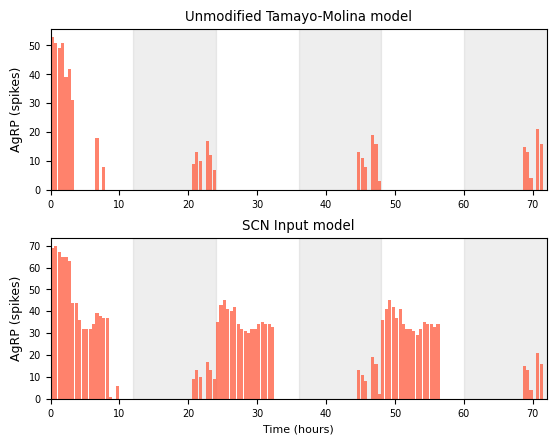

In [79]:
fig, axes = plt.subplots(2,1)

plot.plot_spike_counts(res=dmh, axes=axes[1], meal_spans=[], neurons=["A"], zscore=False, t_range=(0,72.0))
plot.plot_spike_counts(res=off, axes=axes[0], meal_spans=[], neurons=["A"], zscore=False, t_range=(0,72.0))
axes[0].set_xlabel("")
axes[0].set_title("Unmodified Tamayo-Molina model")
axes[1].set_title("SCN Input model")
plt.subplots_adjust(hspace=0.3)

plt.show()

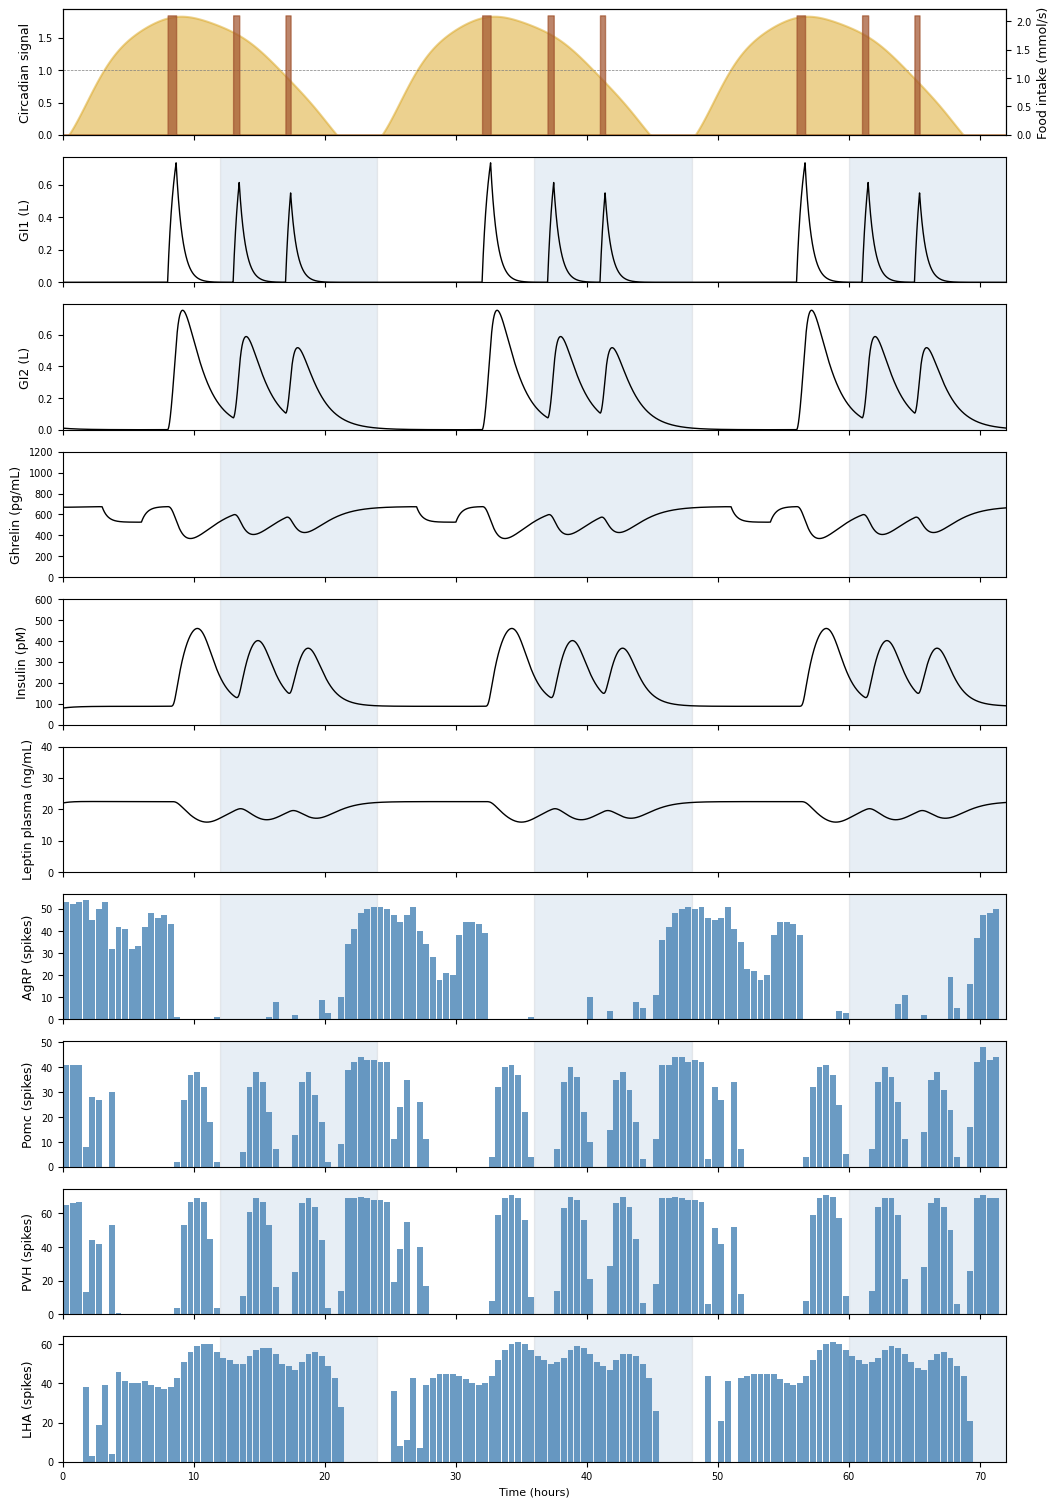

In [48]:
replicate_figures.main(replication)
plt.show()

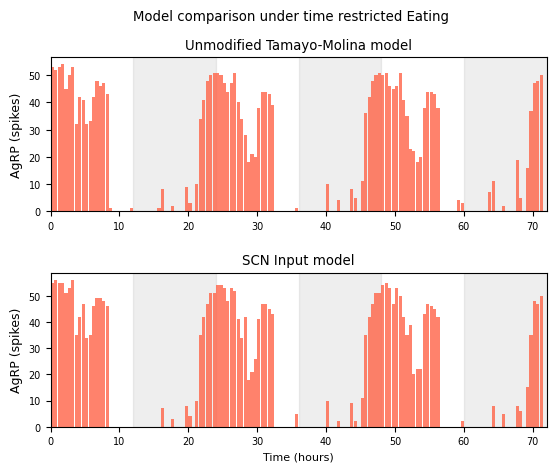

In [49]:
fig, axes = plt.subplots(2,1)

plot.plot_spike_counts(res=tre, axes=axes[1], meal_spans=[], neurons=["A"], zscore=False, t_range=(0,72.0))
plot.plot_spike_counts(res=replication, axes=axes[0], meal_spans=[], neurons=["A"], zscore=False, t_range=(0,72.0))
axes[0].set_xlabel("")
axes[0].set_title("Unmodified Tamayo-Molina model")
axes[1].set_title("SCN Input model")
plt.suptitle("Model comparison under time restricted Eating")
plt.subplots_adjust(hspace=0.4)

plt.show()

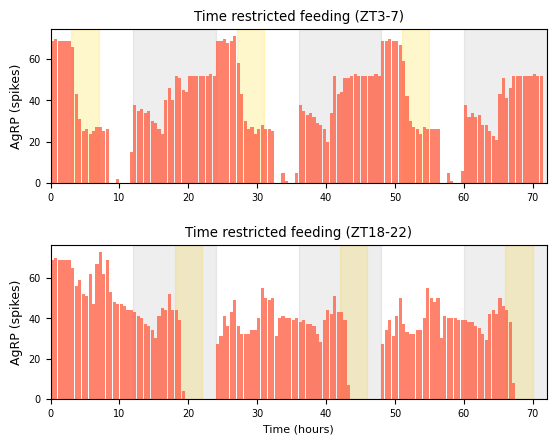

In [63]:
fig, axes = plt.subplots(2,1)

tre_3_7_windows = [(3,7), (27,31), (51,55)]
tre_18_22_windows = [(18,22), (42,46), (66,70)]

plot.plot_spike_counts(res=tre_18_22, axes=axes[1], meal_spans=tre_18_22_windows, neurons=["A"], zscore=False, t_range=(0,72.0))
plot.plot_spike_counts(res=tre_3_7, axes=axes[0], meal_spans=tre_3_7_windows, neurons=["A"], zscore=False, t_range=(0,72.0))
axes[0].set_xlabel("")
axes[0].set_title("Time restricted feeding (ZT3-7)")
axes[1].set_title("Time restricted feeding (ZT18-22)")

plt.subplots_adjust(hspace=0.4)

plt.show()

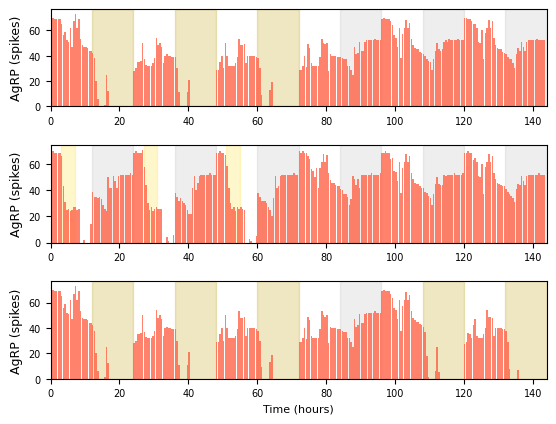

In [90]:
fig, axes = plt.subplots(3,1)

tre_3_7_windows = [(3,7), (27,31), (51,55)]
tre_18_22_windows = [(18,22), (42,46), (66,70)]
standard_windows = [(12,24), (36,48), (60,72)]
sfs_windows = [(12,24), (36,48), (60,72), (108,120), (132,144)]

plot.plot_spike_counts(res=standard, axes=axes[0], meal_spans=standard_windows, neurons=["A"], zscore=False, t_range=(0,144.0))
plot.plot_spike_counts(res=tre_3_7_fast, axes=axes[1], meal_spans=tre_3_7_windows, neurons=["A"], zscore=False, t_range=(0,144.0))
plot.plot_spike_counts(res=sfs, axes=axes[2], meal_spans=sfs_windows, neurons=["A"], zscore=False, t_range=(0,144.0))

axes[0].set_xlabel("")
axes[1].set_xlabel("")

#axes[0].set_title("Time restricted feeding (ZT3-7)")
#axes[1].set_title("Time restricted feeding (ZT18-22)")

plt.subplots_adjust(hspace=0.4)

plt.show()